Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.DMLREH_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.DMLREH_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- FASE 1: Entrenando capas finales ---
Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.4864 - loss: 1.8866 - val_accuracy: 0.8111 - val_loss: 0.6892
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.7451 - loss: 0.8275 - val_accuracy: 0.8386 - val_loss: 0.5350
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.7995 - loss: 0.6436 - val_accuracy: 0.8381 - val_loss: 0.5229
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.8215 - loss: 0.5488 - val_accuracy: 0.8585 - val_loss: 0.4520
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.8451 - loss: 0.4831 - val_accuracy: 0.8542 - val_loss: 0.4479
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.8516 - loss: 0.4661 - val_accuracy: 0.8583 - val_loss: 0.44

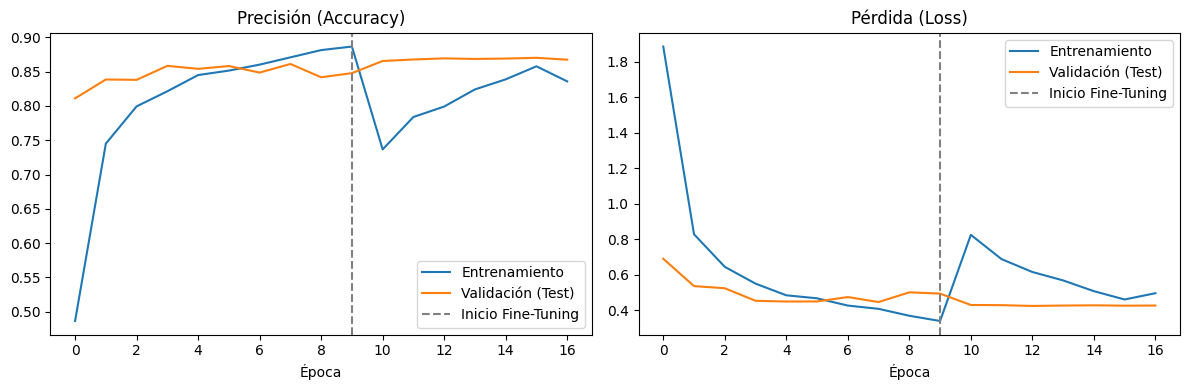

In [3]:
# 1. Instalación de dependencias faltantes
import sys
!{sys.executable} -m pip install --upgrade protobuf tensorflow-datasets importlib-resources -q

import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

# 2. Parámetros principales
IMG_SIZE = 160
BATCH_SIZE = 32
EPOCHS_PHASE1 = 10
EPOCHS_PHASE2 = 15

# 3. Carga del conjunto de datos Oxford-IIIT Pet
(ds_train, ds_test), info = tfds.load(
    'oxford_iiit_pet',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)
NUM_CLASSES = info.features['label'].num_classes

# 4. Data Augmentation y Preprocesamiento
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
], name="data_augmentation")

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

train_dataset = (
    ds_train
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    ds_test
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# 5. Arquitectura del Modelo (Transfer Learning con MobileNetV2)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Congelar base inicialmente

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)  # Regularización contra overfitting
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# 6. Fase 1: Entrenamiento de la cabecera de clasificación
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_pet_model.keras', monitor='val_accuracy', save_best_only=True)
]

print("--- FASE 1: Entrenando capas finales ---")
history_1 = model.fit(
    train_dataset,
    epochs=EPOCHS_PHASE1,
    validation_data=test_dataset,
    callbacks=callbacks
)

# 7. Fase 2: Fine-Tuning (Descongelar bloques superiores)
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Tasa de aprendizaje baja
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- FASE 2: Ajuste Fino (Fine-Tuning) ---")
history_2 = model.fit(
    train_dataset,
    epochs=EPOCHS_PHASE1 + EPOCHS_PHASE2,
    initial_epoch=history_1.epoch[-1] + 1,
    validation_data=test_dataset,
    callbacks=callbacks
)

# 8. Evaluación final en el conjunto de Test
test_loss, test_acc = model.evaluate(test_dataset)
print(f"\n==========================================")
print(f" Accuracy final en Test: {test_acc * 100:.2f}%")
print(f"==========================================")

# 9. Gráficas de Diagnóstico (Evaluación de Overfitting / Underfitting)
acc = history_1.history['accuracy'] + history_2.history['accuracy']
val_acc = history_1.history['val_accuracy'] + history_2.history['val_accuracy']
loss = history_1.history['loss'] + history_2.history['loss']
val_loss = history_1.history['val_loss'] + history_2.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Entrenamiento')
plt.plot(val_acc, label='Validación (Test)')
plt.axvline(x=len(history_1.history['accuracy'])-1, color='gray', linestyle='--', label='Inicio Fine-Tuning')
plt.title('Precisión (Accuracy)')
plt.xlabel('Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Entrenamiento')
plt.plot(val_loss, label='Validación (Test)')
plt.axvline(x=len(history_1.history['loss'])-1, color='gray', linestyle='--', label='Inicio Fine-Tuning')
plt.title('Pérdida (Loss)')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()